<a href="https://colab.research.google.com/github/jackhungf/modeling-project/blob/main/Final_Freq_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Summary

This frequency analysis project uses French Motor Third-Party Liability Insurance Claims Data to explore data patterns, fit GLMs, validate the models’ predictive performance, and simulate with the best model.

To avoid clutter, only selected outputs are displayed, and part of the full code is commented out.

# Roadmap
1. Data exploration
    * Data check and summary
    * Univariate analysis
    * Multivariate analysis
    * Further investigated patterns

2. Model selection
    * Poisson
    * Negative Binomial
    * Diagnostics

3. Validation
    * Predictive performance on Poisson, NB, and NB-Lasso

4. Simulation of a high-risk subgroup



# 1. Data exploration




## 1.1 Data cleaning and inspection

### Basic data inspection

In [12]:

# Import and audit freMTPL2freq

import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount("/content/drive")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

# Import data from OpenML
# df = fetch_openml(data_id=41214, as_frame=True)["data"].copy()

# Or import from csv
path = "/content/drive/MyDrive/Colab Notebooks/actuarial project/Freq analysis/freMTPL2freq (1).csv"
df = pd.read_csv(path)

display(df.info())
display(df.describe().T)

df["VehGas"]=df["VehGas"].astype("category")
df["Area"]=df["Area"].astype("category")
df["VehBrand"]=df["VehBrand"].astype("category")
df["Region"]=df["Region"].astype("category")


Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   Area        678013 non-null  object 
 4   VehPower    678013 non-null  int64  
 5   VehAge      678013 non-null  int64  
 6   DrivAge     678013 non-null  int64  
 7   BonusMalus  678013 non-null  int64  
 8   VehBrand    678013 non-null  object 
 9   VehGas      678013 non-null  object 
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  object 
dtypes: float64(2), int64(6), object(4)
memory usage: 62.1+ MB


None

,count,mean,std,min,25%,50%,75%,max
IDpol,678013.0,2.621857e+06,1.641783e+06,1.000000,1157951.00,2272152.00,4046274.00,6114330.00
ClaimNb,678013.0,5.324677e-02,2.401173e-01,0.000000,0.00,0.00,0.00,16.00
Exposure,678013.0,5.287501e-01,3.644415e-01,0.002732,0.18,0.49,0.99,2.01
VehPower,678013.0,6.454631e+00,2.050906e+00,4.000000,5.00,6.00,7.00,15.00
VehAge,678013.0,7.044265e+00,5.666232e+00,0.000000,2.00,6.00,11.00,100.00
DrivAge,678013.0,4.549912e+01,1.413744e+01,18.000000,34.00,44.00,55.00,100.00
BonusMalus,678013.0,5.976150e+01,1.563666e+01,50.000000,50.00,50.00,64.00,230.00
Density,678013.0,1.792422e+03,3.958647e+03,1.000000,92.00,393.00,1658.00,27000.00


### Transformation and train/test split

In [13]:
df["ClaimNb_adjusted"]=np.log1p(df["ClaimNb"]/df["Exposure"])

df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)
# df_train = df_train.sample(frac=0.05, random_state=42).copy()   # sub-sample

**Finding:**

The data have **no missing values**.

**Decision:**

Both `VehAge` and `DrivAge` reach 100 which seem to be policy feature rather than error after inspection so are **kept as they are**.



`ClaimNb` is transformed to `ClaimNb_adjusted`=log((ClaimNb/Exposure)+1) **for visualization** as Poisson and Negative Binomial will be fitted with an exposure offset.

Train/test split is performed for later validation. df_train is used for analysis and modeling.





## 1.2 Univariate analysis

### Numeric


===============Numeric variable: Density===============


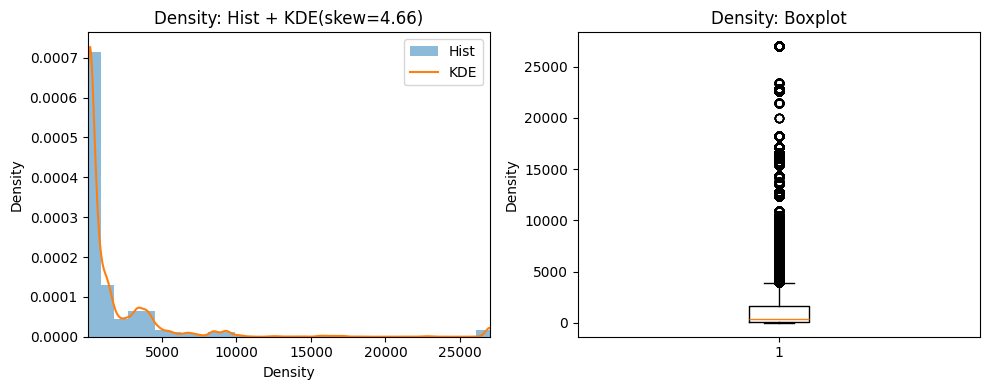

In [14]:
numeric_cols = ["ClaimNb_adjusted", "VehAge", "DrivAge", "BonusMalus", "VehPower", "Density"]
categorical_cols = ["Area", "VehBrand", "VehGas",  "Region"]

# ---------- NUMERIC VARIABLES ----------
# for col in numeric_cols:
#     s = df_train[col]

#     print(f"\n===============Numeric variable: {col}===============")

#     fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#     # Histogram + KDE
#     s.plot(kind="hist", bins=30, density=True, alpha=0.5,
#            ax=axes[0], label="Hist")
#     s.plot(kind="kde", ax=axes[0], label="KDE")
#     axes[0].set_xlim(s.min(), s.max())
#     axes[0].set_title(f"{col}: Hist + KDE(skew={s.skew():.2f})")
#     axes[0].set_xlabel(col)
#     axes[0].set_ylabel("Density")
#     axes[0].legend()

#     # Boxplot
#     axes[1].boxplot(s, vert=True, showfliers=True)
#     axes[1].set_title(f"{col}: Boxplot")
#     axes[1].set_ylabel(col)

#     plt.tight_layout()
#     plt.show()

s = df_train["Density"]

print(f"\n===============Numeric variable: {"Density"}===============")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram + KDE
s.plot(kind="hist", bins=30, density=True, alpha=0.5,
        ax=axes[0], label="Hist")
s.plot(kind="kde", ax=axes[0], label="KDE")
axes[0].set_xlim(s.min(), s.max())
axes[0].set_title(f"{"Density"}: Hist + KDE(skew={s.skew():.2f})")
axes[0].set_xlabel("Density")
axes[0].set_ylabel("Density")
axes[0].legend()

# Boxplot
axes[1].boxplot(s, vert=True, showfliers=True)
axes[1].set_title(f"{"Density"}: Boxplot")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()



### Categorical


===============Categorical variable: VehBrand===============
           count  proportion
VehBrand                    
B1        130035    0.239736
B10        14103    0.026001
B11        10818    0.019944
B12       132766    0.244771
B13         9697    0.017878
B14         3225    0.005946
B2        128079    0.236129
B3         42824    0.078951
B4         20112    0.037079
B5         27758    0.051175
B6         22993    0.042390


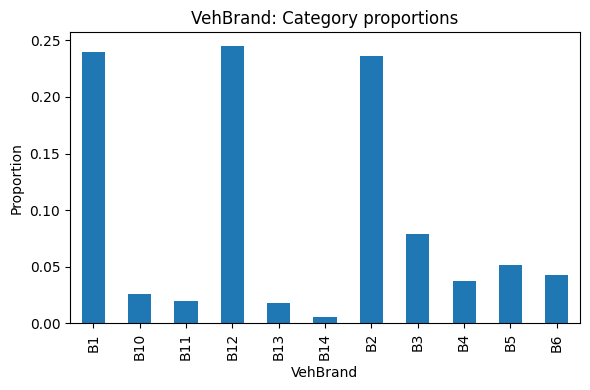

In [15]:

# ---------- CATEGORICAL VARIABLES ----------
# for col in categorical_cols:
#     cat = df_train[col]

#     print(f"\n===============Categorical variable: {col}===============")

#     # Frequency table sorted by category value
#     freq = (
#         cat.value_counts(dropna=False)
#            .sort_index()           # sort by the category value
#            .rename("count")
#            .to_frame()
#     )
#     freq["proportion"] = freq["count"] / freq["count"].sum()

#     print(freq)

#     # Bar plot of proportions, sorted by value
#     plt.figure(figsize=(6, 4))
#     freq["proportion"].plot(kind="bar")
#     plt.title(f"{col}: Category proportions")
#     plt.ylabel("Proportion")
#     plt.xlabel(col)
#     plt.tight_layout()
#     plt.show()


cat = df_train["VehBrand"]

print(f"\n===============Categorical variable: {"VehBrand"}===============")

# Frequency table sorted by category value
freq = (
    cat.value_counts(dropna=False)
        .sort_index()           # sort by the category value
        .rename("count")
        .to_frame()
)
freq["proportion"] = freq["count"] / freq["count"].sum()

print(freq)

# Bar plot of proportions, sorted by value
plt.figure(figsize=(6, 4))
freq["proportion"].plot(kind="bar")
plt.title(f"{"VehBrand"}: Category proportions")
plt.ylabel("Proportion")
plt.xlabel("VehBrand")
plt.tight_layout()
plt.show()

**Finding:**

`ClaimNb`, `density`, `VehAge`, `DrivAge`, and `BonusMalus` are **right skewed with outliers** captured by boxplot. They may require log-transformation or binning.

`VehBrand`, `VehPower` and `Region` have **categories that are rare**. They may require binning together later.

## 1.3 Multivariate analysis

### Num x Num


===============Scatter plot===============


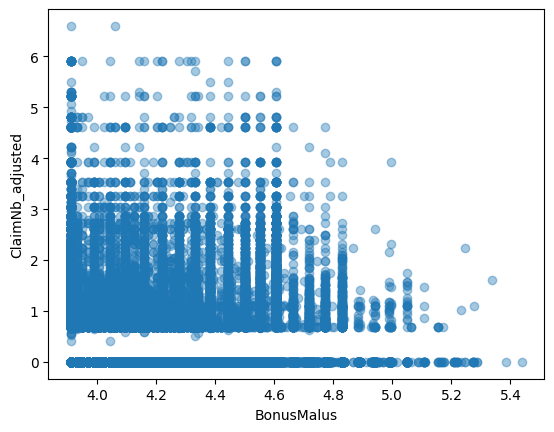


===============Heatmap===============


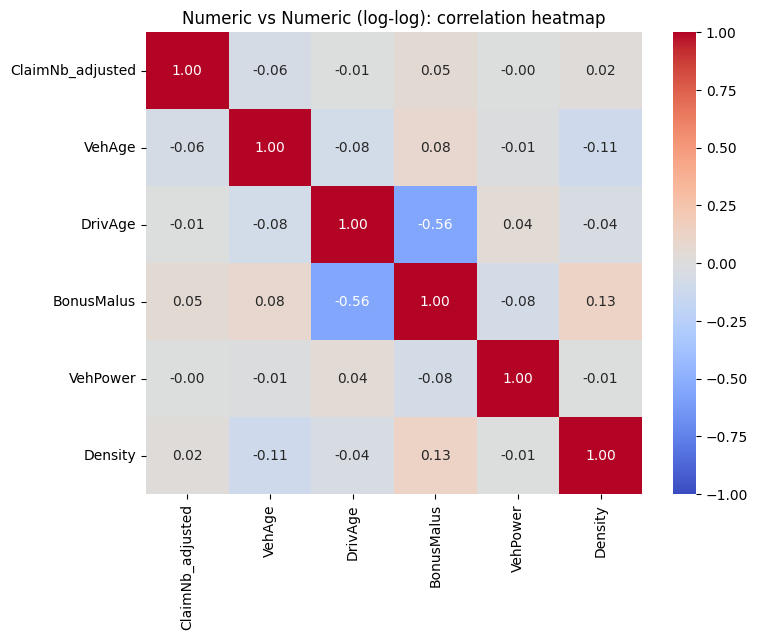

In [16]:
# -------- NUMERIC vs NUMERIC --------

num_df = df_train[numeric_cols].copy()

# # Scatter matrix (pairplot style)
# sns.pairplot(num_df, diag_kind=None, plot_kws={"alpha": 0.4, "s": 10})
# plt.suptitle("Numeric vs Numeric: scatter matrix", y=1.02)
# plt.show()


temp_cols = ["DrivAge", "BonusMalus", "VehPower", "Density"]
for i in temp_cols:
  num_df[i]=np.log(num_df[i])
num_df["VehAge"]=np.log(num_df["VehAge"]+1)

# sns.pairplot(num_df, diag_kind=None, plot_kws={"alpha": 0.4, "s": 10})
# plt.suptitle("Numeric vs Numeric (log-log): scatter matrix", y=1.02)
# plt.show()

# Scatter plot highlight
print(f"\n===============Scatter plot===============")
plt.scatter(num_df['BonusMalus'], num_df['ClaimNb_adjusted'], alpha=0.4)
plt.xlabel('BonusMalus')
plt.ylabel('ClaimNb_adjusted')
plt.show()

print(f"\n===============Heatmap===============")
# Correlation heatmap
corr = num_df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Numeric vs Numeric (log-log): correlation heatmap")
plt.show()

**Finding**:

The pair scatter plots seem to suggest nonlinear pattern with respect to `ClaimNb_adjusted`. This requires further investigation, as most of the apparent patterns are likely driven by outliers.

We will [further investigate](#scrollTo=HbJnb9EGqVeF) `BonusMalus` later, as the scatter plot appears to suggest a negative relationship with claims, whereas the opposite would be expected.

The heatmap of correlations among the numeric variables suggests that the predictors are unlikely to have collinearity problems.


### Num x Cat

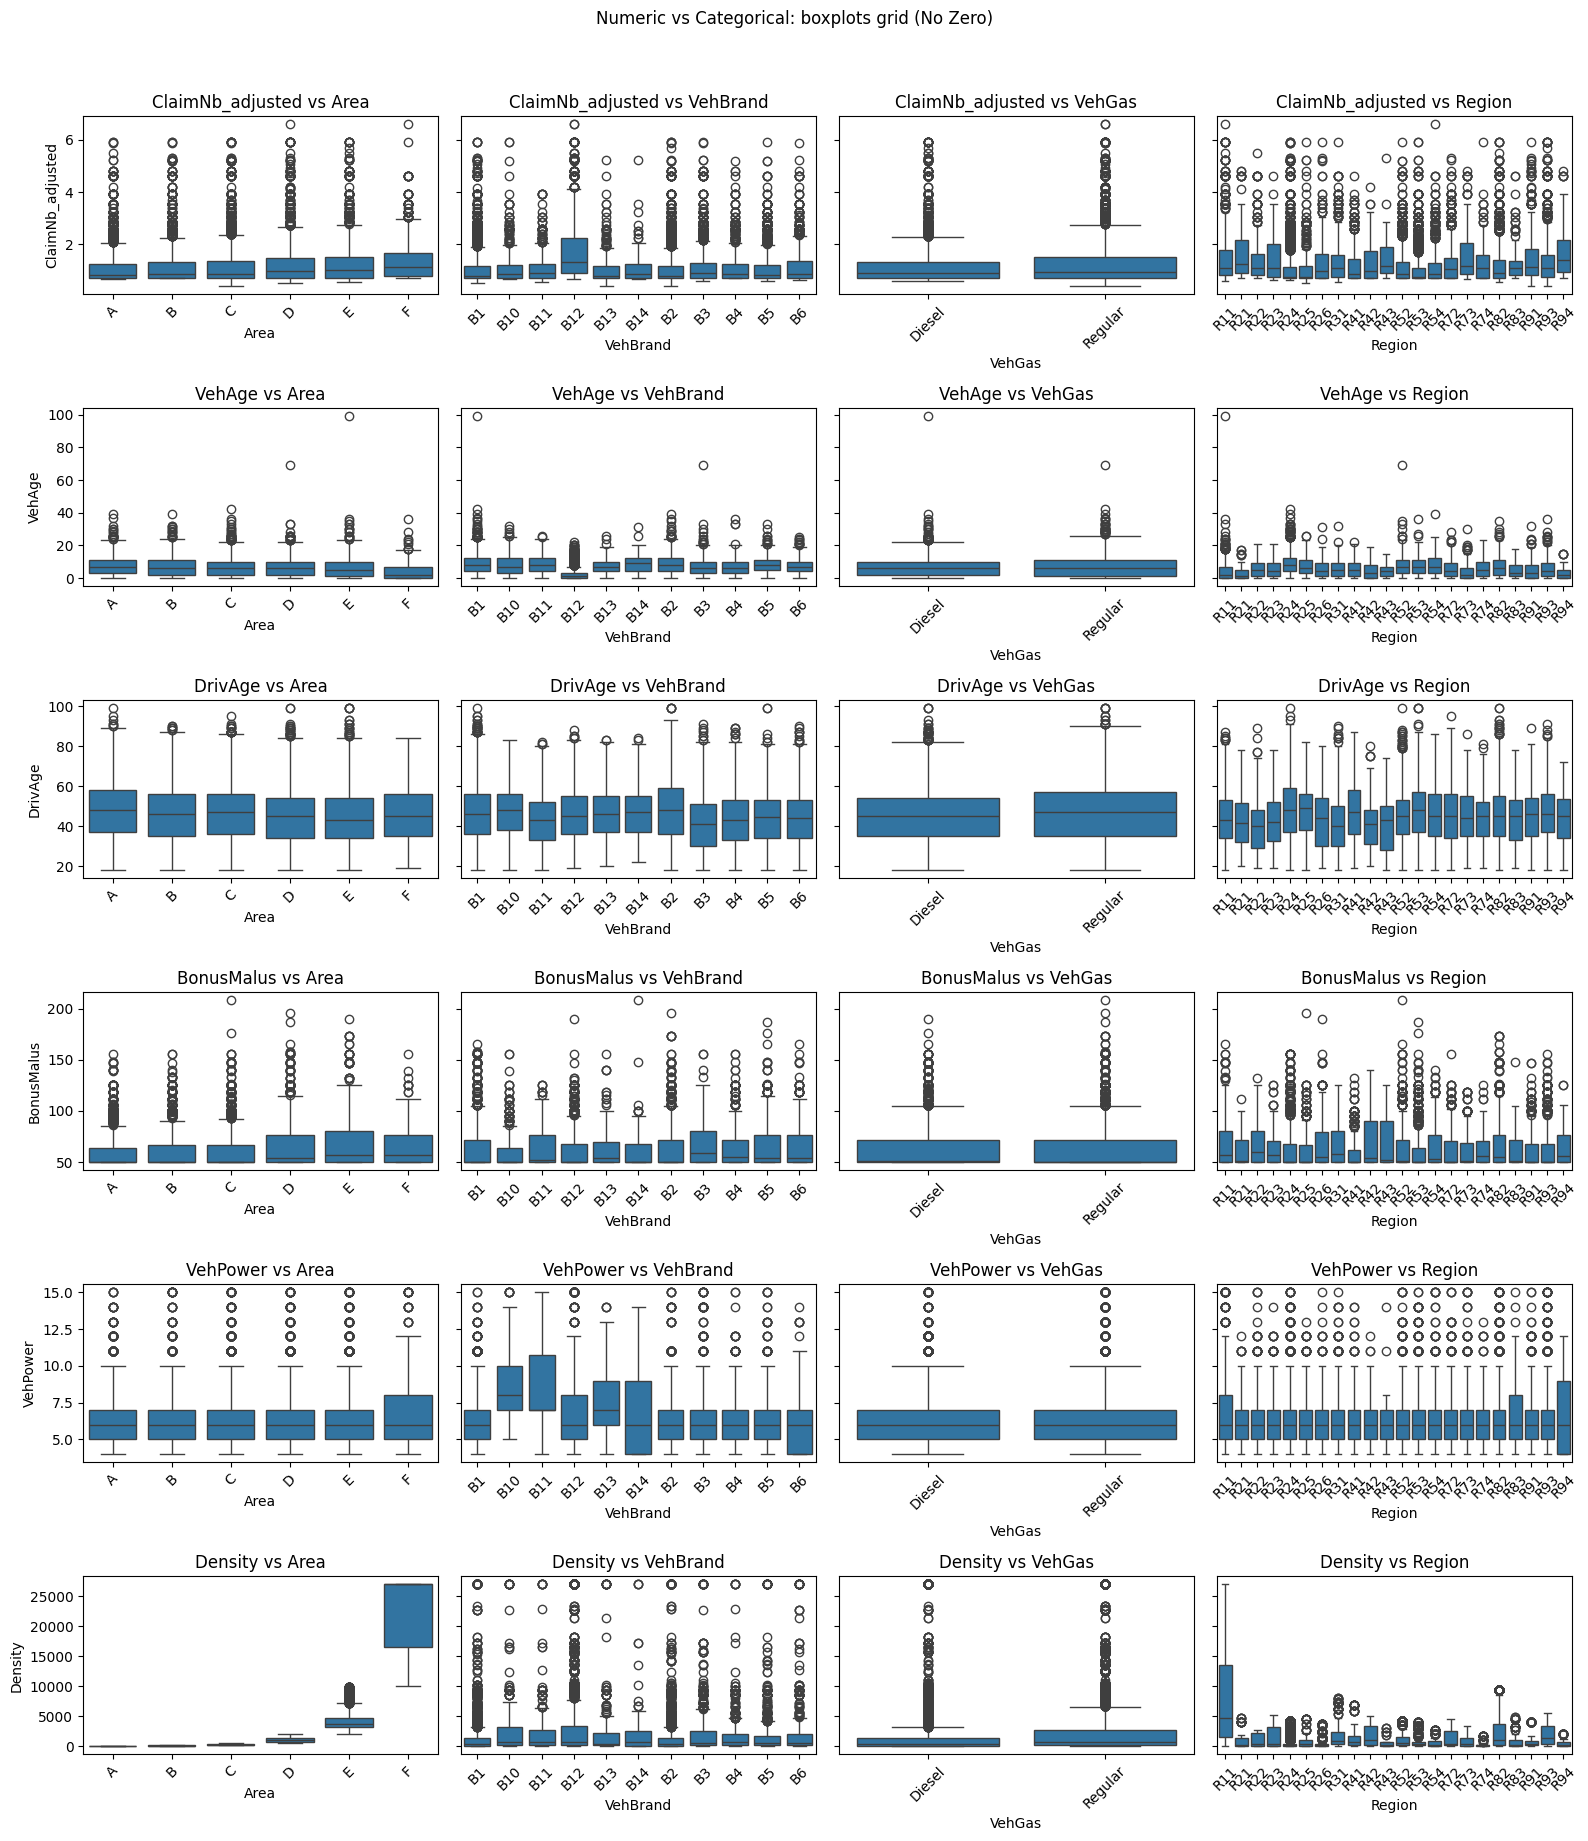

In [17]:
# -------- NUMERIC vs CATEGORICAL --------

n_num = len(numeric_cols)
n_cat = len(categorical_cols)

# fig, axes = plt.subplots(n_num, n_cat, figsize=(4*n_cat, 3*n_num), sharey="row")

# for i, num in enumerate(numeric_cols):
#     for j, cat in enumerate(categorical_cols):
#         ax = axes[i, j] if n_num > 1 else axes[j]  # handle 1-row edge case
#         sns.boxplot(x=df_train[cat], y=df_train[num], ax=ax)
#         ax.set_xlabel(cat)
#         ax.set_ylabel(num if j == 0 else "")
#         ax.set_title(f"{num} vs {cat}")
#         # rotate x labels for readability
#         ax.tick_params(axis="x", rotation=45)

# plt.suptitle("Numeric vs Categorical: boxplots grid", y=1.02)
# plt.tight_layout()
# plt.show()

# -------- NUMERIC vs CATEGORICAL (zero removed) --------

df_train_0=df_train[df_train["ClaimNb_adjusted"]>0]
fig, axes = plt.subplots(n_num, n_cat, figsize=(4*n_cat, 3*n_num), sharey="row")

for i, num in enumerate(numeric_cols):
    for j, cat in enumerate(categorical_cols):
        ax = axes[i, j] if n_num > 1 else axes[j]  # handle 1-row edge case
        sns.boxplot(x=df_train_0[cat], y=df_train_0[num], ax=ax)
        ax.set_xlabel(cat)
        ax.set_ylabel(num if j == 0 else "")
        ax.set_title(f"{num} vs {cat}")
        # rotate x labels for readability
        ax.tick_params(axis="x", rotation=45)

plt.suptitle("Numeric vs Categorical: boxplots grid (No Zero)", y=1.02)
plt.tight_layout()
plt.show()

**Finding**:

The boxplots based on the full df_train look broadly similar, mainly because of the influence of outliers. A **non-zero version**, which removes observations with zero claims, is also examined to help identify clearer patterns.

We can see that `VehBrand` B12 appears to be associated with **higher non-zero claims** and **lower `VehAge`.** We will [investigate further](#scrollTo=A3KaKgJq0ToQ) on this.

We can also see that the boxplots for `Density` and `Area` show an **increasing pattern** across the alphabetical order of `Area`. We will [investigate further](#scrollTo=pjuNTiKTfQpX) on this as well.

### Cat x Cat

==========================Now showing mean claim==========================


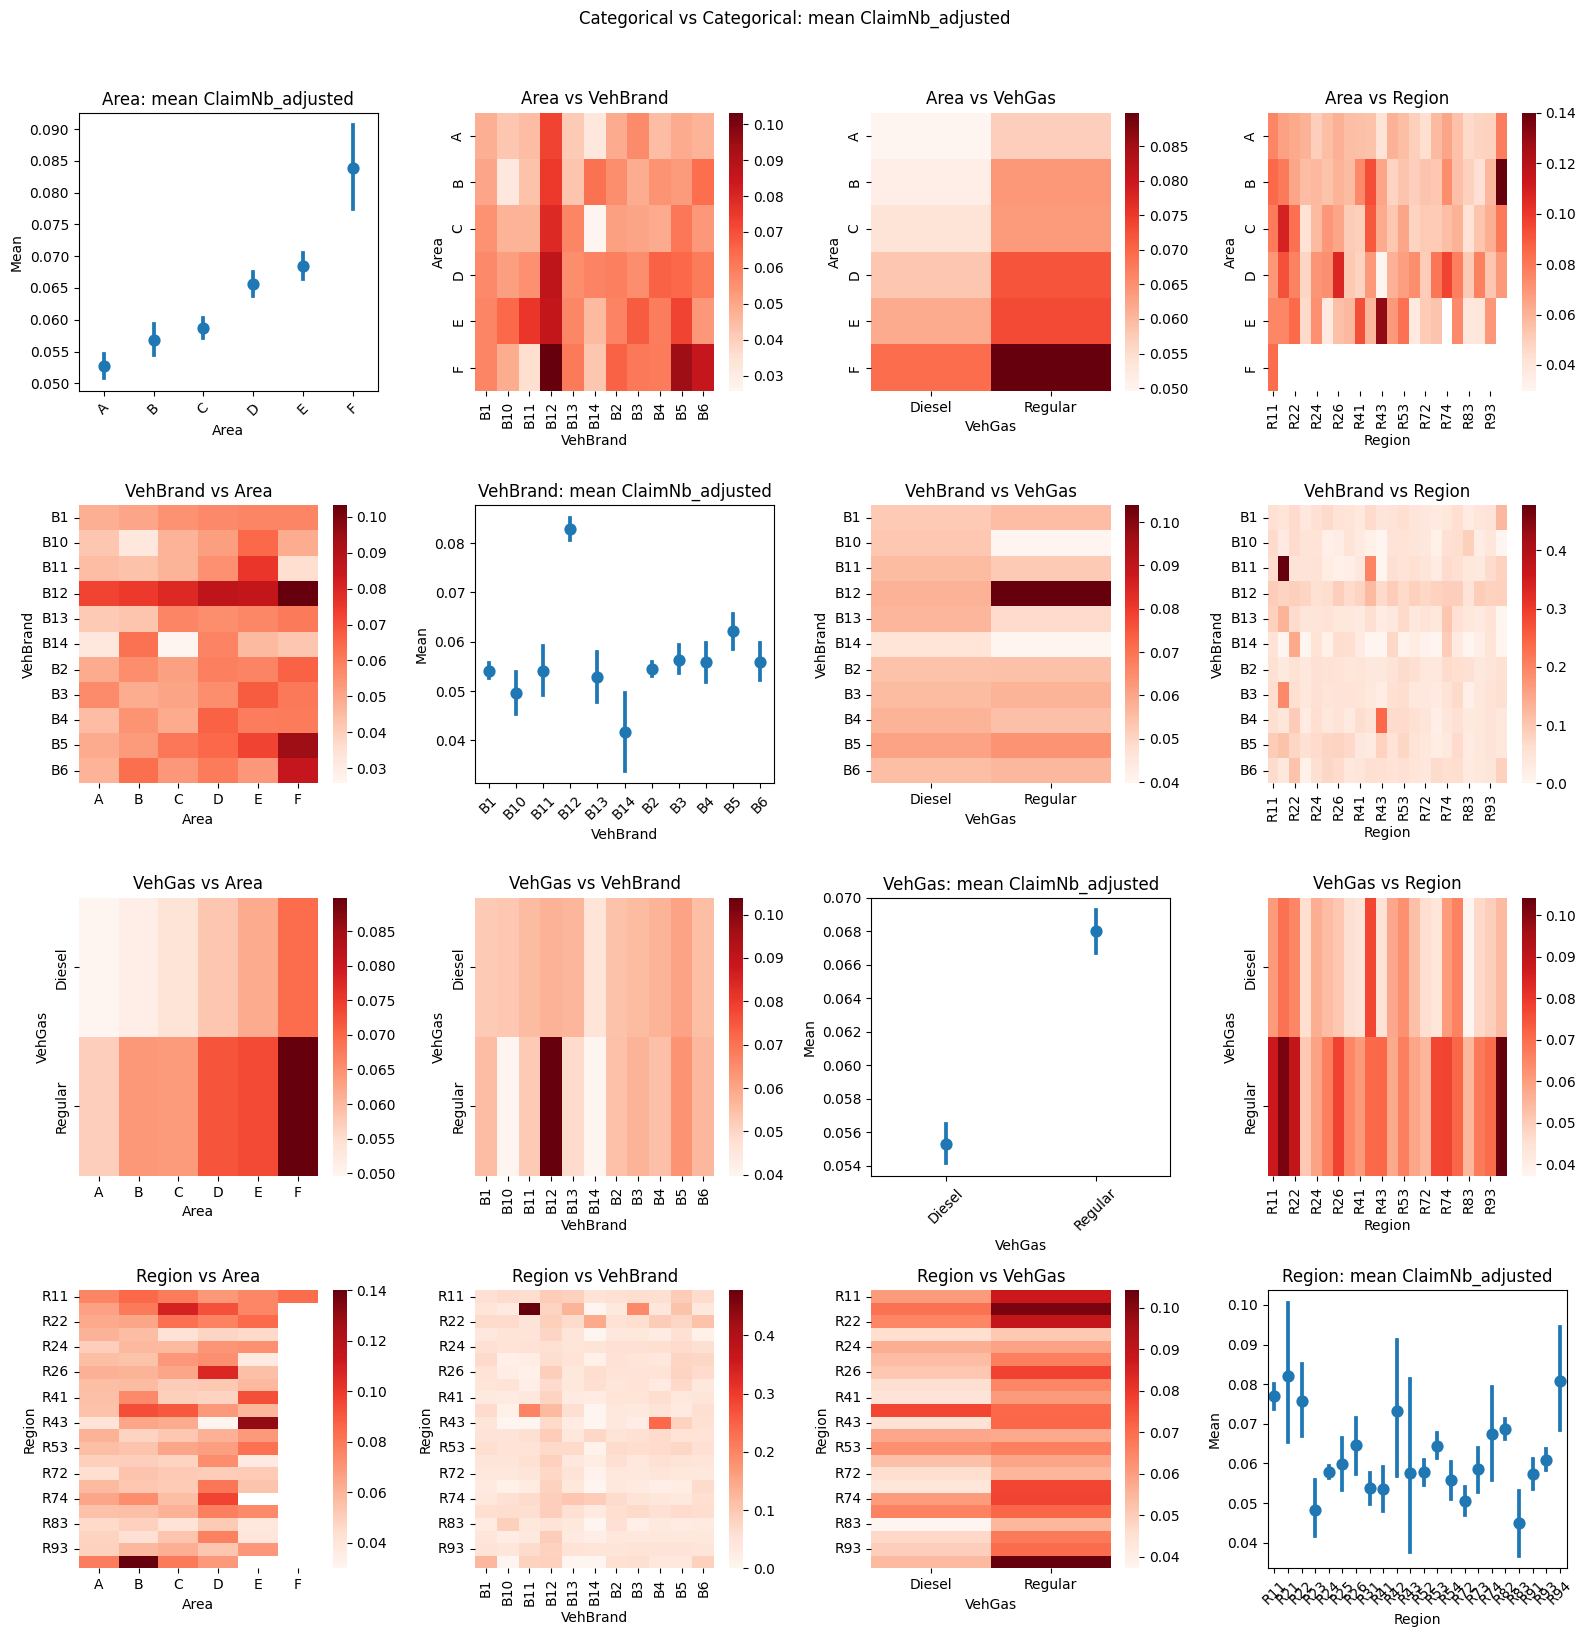

In [18]:
# -------- CATEGORICAL vs CATEGORICAL --------

cat_df = df_train[categorical_cols]

n_cat = len(categorical_cols)
# fig, axes = plt.subplots(n_cat, n_cat, figsize=(4*n_cat, 4*n_cat))

# for i, cat1 in enumerate(categorical_cols):
#     for j, cat2 in enumerate(categorical_cols):
#         ax = axes[i, j]

#         if i == j:
#             # On the diagonal, show just the frequency barplot of that single variable
#             freq = cat_df[cat1].value_counts(normalize=True).sort_index()
#             sns.barplot(x=freq.index, y=freq.values, ax=ax)
#             ax.set_title(f"{cat1}: proportions")
#             ax.set_xlabel(cat1)
#             ax.set_ylabel("Prop.")
#             ax.tick_params(axis="x", rotation=45)
#         else:
#             # Off-diagonal: heatmap of joint proportions
#             ct = pd.crosstab(cat_df[cat1], cat_df[cat2], normalize="all")
#             sns.heatmap(ct, ax=ax, cmap="Blues")
#             ax.set_title(f"{cat1} vs {cat2}")
#             ax.set_xlabel(cat2)
#             ax.set_ylabel(cat1)

# plt.suptitle("Categorical vs Categorical: proportion", y=1.02)
# plt.tight_layout()
# plt.show()

print("==========================Now showing mean claim==========================")

fig, axes = plt.subplots(n_cat, n_cat, figsize=(4*n_cat, 4*n_cat))

for i, cat1 in enumerate(categorical_cols):
    for j, cat2 in enumerate(categorical_cols):
        ax = axes[i, j]

        if i == j:
            # On the diagonal, show just the frequency barplot of that single variable
            freq = cat_df[cat1].value_counts(normalize=True).sort_index()
            sns.pointplot(data=df_train, x=cat1, y="ClaimNb_adjusted", ax=ax, linestyle='none')
            ax.set_title(f"{cat1}: mean ClaimNb_adjusted")
            ax.set_xlabel(cat1)
            ax.set_ylabel("Mean")
            ax.tick_params(axis="x", rotation=45)
        else:
            # Off-diagonal: heatmap of mean ClaimNb_adjusted
            ct = pd.crosstab(cat_df[cat1], cat_df[cat2], values=df_train['ClaimNb_adjusted'], aggfunc="mean")
            sns.heatmap(ct, ax=ax, cmap="Reds")
            ax.set_title(f"{cat1} vs {cat2}")
            ax.set_xlabel(cat2)
            ax.set_ylabel(cat1)

plt.suptitle("Categorical vs Categorical: mean ClaimNb_adjusted", y=1.02)
plt.tight_layout()
plt.show()

**Finding**:

Looking at the red mean-claim plots on the diagonal, we can see that `Area` and `VehGas` suggest **substantial differences** in mean claim frequency. `VehBrand` B12 also stands out, as noted earlier.

The `Area` x `VehGas` mean heatmap shows an interesting **increasing pattern** across the alphabetical order of `Area`, as well as **differences in magnitude** between Diesel and Regular. We will [furthre investigate](#scrollTo=TGlvZCKuALqf) later.


## 1.4 Further investigation


### BonusMalus and Claim

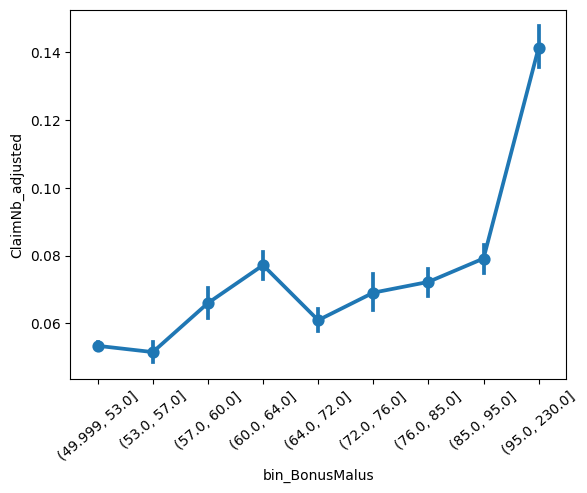

In [19]:
# Mean claim plot by percentile bins.
df_train["bin_BonusMalus"]=pd.qcut(df_train['BonusMalus'],q=20, duplicates="drop")
sns.pointplot(data=df_train,x="bin_BonusMalus", y="ClaimNb_adjusted")
plt.xticks(rotation=40)
plt.show()



We are inspecting the relationship between claim and `BounusMalus` as we have seen the [unlikely scatter plot](#scrollTo=8idIQBUPJp70&line=3&uniqifier=1) of them.

**Takeaway**:

The **mean plot of percentile bins** of `BonusMalus` shows an **upward trend** which aligns with expectation. This confirms the scatter plot was affected by outliers and didn't show clear pattern.

### B12 and VehAge and Claim

===============Scatter plots of claims against VehAge by VehBrand===============


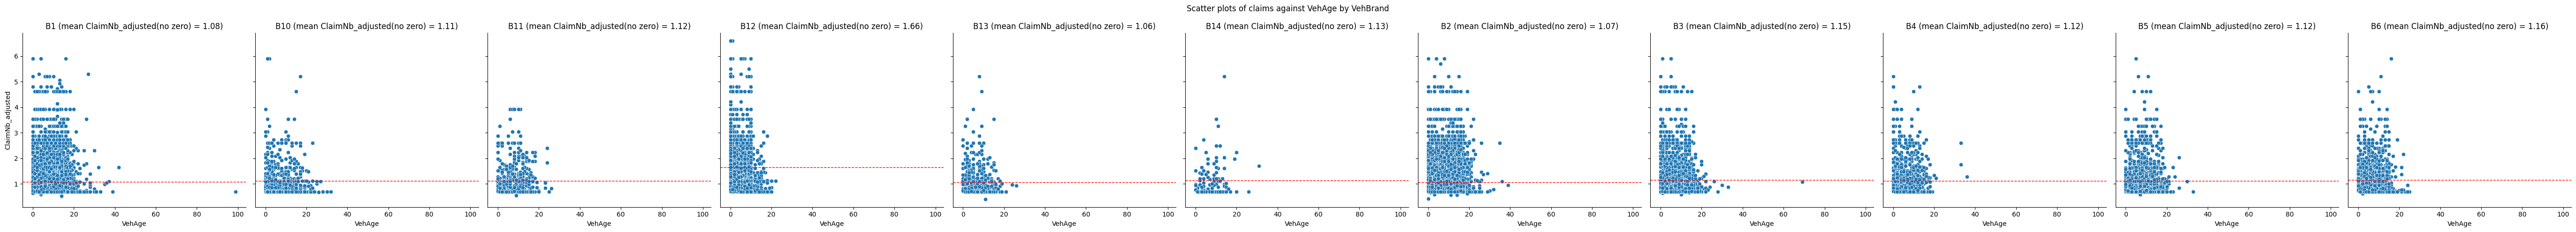

===============Grouping VehBrand into B12 and Others===============


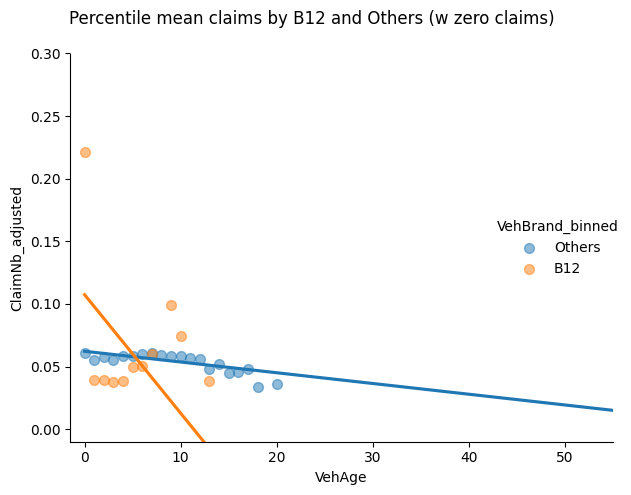

In [20]:
df_b12vehage=df_train[df_train["ClaimNb_adjusted"]>0]

print("===============Scatter plots of claims against VehAge by VehBrand===============")
g1=sns.relplot(
    data=df_b12vehage,
    x="VehAge",
    y="ClaimNb_adjusted",
    col="VehBrand",   # separate small plot per category
    kind="scatter",
)
g1.figure.suptitle("Scatter plots of claims against VehAge by VehBrand")
mean_y = df_b12vehage.groupby("VehBrand",observed=False)["ClaimNb_adjusted"].mean()

# Add a horizontal mean line per VehBrand value
for ax, (cat_value, y_mean) in zip(g1.axes.flat, mean_y.items()):
    ax.axhline(y_mean, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{cat_value} (mean ClaimNb_adjusted(no zero) = {y_mean:.2f})")

plt.tight_layout()
plt.show()


# Binning VehBrand into B12 and Others

df_train["VehBrand_binned"] = np.where(
    df_train["VehBrand"] == "B12", "B12", "Others"
)
# logged predictors
num_df["VehBrand_binned"] = np.where(
    df_train["VehBrand"] == "B12", "B12", "Others"
)

print("===============Grouping VehBrand into B12 and Others===============")

# original VehAge
g11=sns.lmplot(
    data=df_train,
    x="VehAge",
    y="ClaimNb_adjusted",
    hue="VehBrand_binned",
    fit_reg=True,
    ci=None,
    x_bins=50,
    scatter_kws={"alpha": 0.5}
)
g11.set(xlim=(-1.5, 55), ylim=(-0.01, 0.3))
g11.figure.suptitle("Percentile mean claims by B12 and Others (w zero claims)")
plt.tight_layout()
plt.show()

# logged VehAge
# g12=sns.lmplot(
#     data=num_df,
#     x="VehAge",
#     y="ClaimNb_adjusted",
#     hue="VehBrand_binned",
#     fit_reg=True,
#     ci=None,
#     x_bins=50,
#     scatter_kws={"alpha": 0.5}
# )
# g12.figure.suptitle("Percentile mean claims by B12 and Others (w zero claims) logged")
# plt.tight_layout()
# plt.show()



Noted by the [num x cat boxplots](#scrollTo=a50h1YHOd7iR&line=5&uniqifier=1), we will look at the relationship between `VehAge`, `VehBrand` and claim frequency.

**Finding**:

First graph: After **removing the zero-claim** cases(ClaimNb_adjusted=0), we can see a visually distinct mean for B12 within `VehBrand`.

**Decision:** An action taken here is to create `VehBrand_binned` that groups B12 separately and combines the rest as other category under `VehBrand`.

Second grpahs: Inspecting the percentile mean of the **full train dataset**, together with an inital OLS by `VehAge` under `VehBrand_binned`, suggests that `VehAge` may have **different effects** in the two groups. It might worth considering an interaction term `VehBrand_binned:VehAge`.

### (Density and Area) and VehGas
From the [plots in num x cat](#scrollTo=a50h1YHOd7iR) we found that `Density` and `Area` shows a pattern.

[`Area` and `VehGas`](#scrollTo=Axae69GWaDwr) also seem to show a trend on mean claims.

**Density and Area**

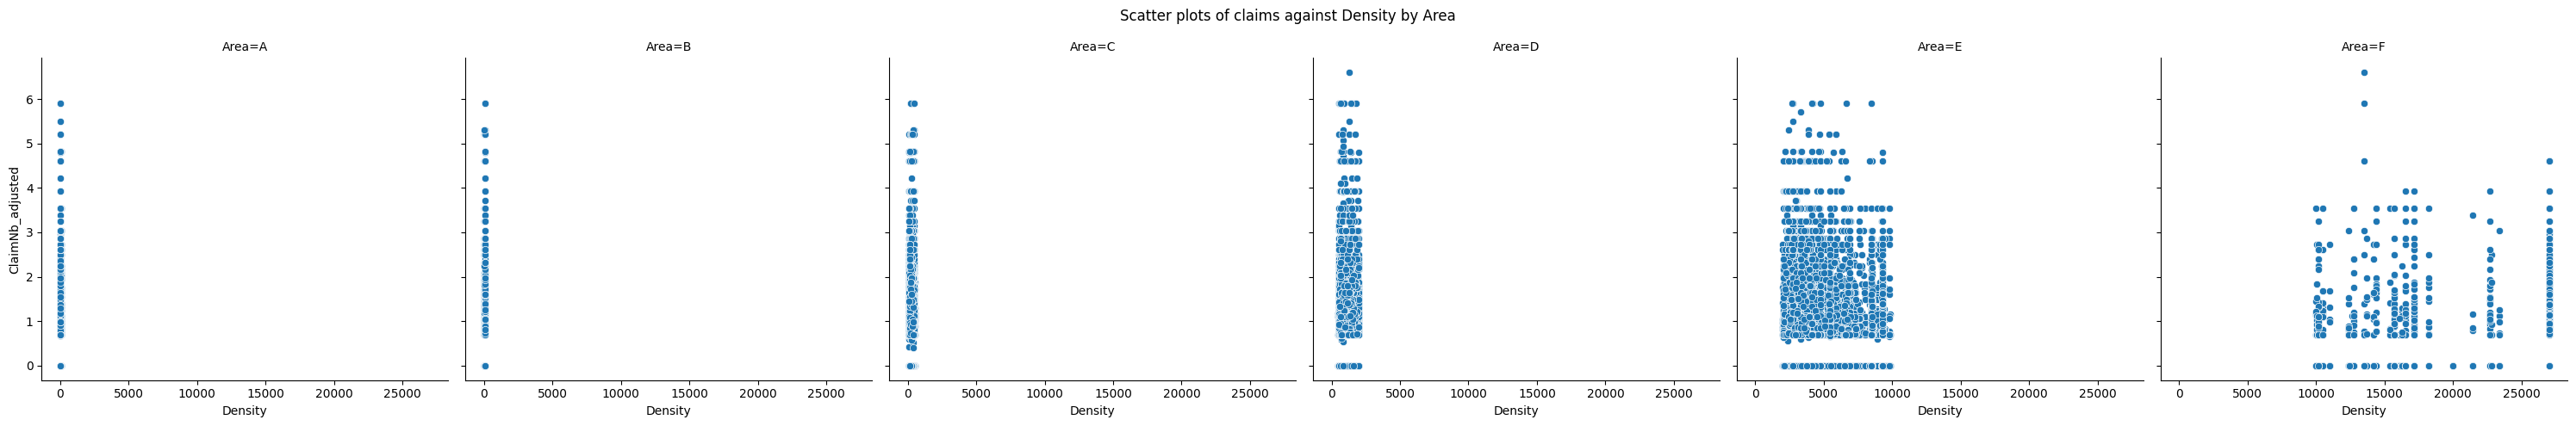

,min_value,q25,median,q75,max_value
Area,,,,,
A,1,16.0,27.0,38.0,50
B,50,59.0,71.0,85.0,100
C,100,149.0,222.0,335.0,500
D,500,722.0,1054.0,1328.0,1993
E,2001,3184.0,3744.0,4762.0,9850
F,10008,16284.0,27000.0,27000.0,27000


In [21]:
g2=sns.relplot(
    data=df_train,
    x="Density",
    y="ClaimNb_adjusted",
    col="Area",   # separate small plot per category
    kind="scatter"
)
g2.figure.suptitle("Scatter plots of claims against Density by Area")
g2.set_titles(template="Area={col_name}")

plt.tight_layout()
plt.show()

summary = df_train.groupby("Area", observed=False)["Density"].agg(
    min_value="min",
    q25=lambda s: s.quantile(0.25),
    median=lambda s: s.quantile(0.50),
    q75=lambda s: s.quantile(0.75),
    max_value="max"
)

summary

**Finding**:

From the plot and summary of `Area` and `Density`, there seems to be **clear boundaries** of density among areas. It suggests `Area` is defined by `Density`, and they could be redundant as predictors if both are included in models.

**VehGas and Area(Density)**

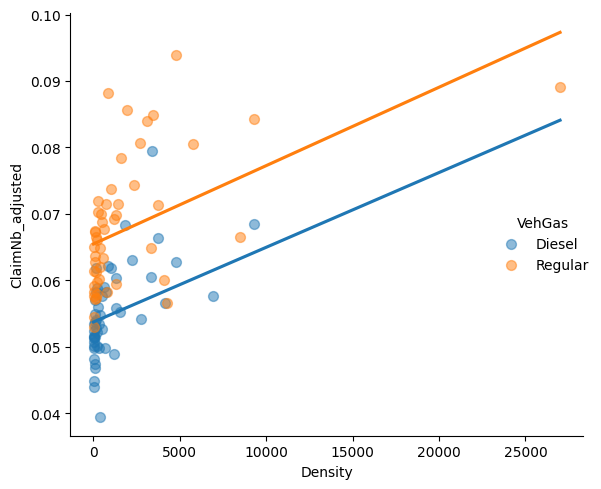

In [22]:
sns.lmplot(
    data=df_train,
    x="Density",
    y="ClaimNb_adjusted",
    hue="VehGas",
    x_bins=50,
    fit_reg=True,
    ci=None,
    scatter_kws={"alpha": 0.5}
)

plt.tight_layout()
plt.show()

**Finding**:

Since we have established `Area` is likely **a derivative** of `Density`, we look at `Density` and `VehGas` directly. The above bins `Density` into 50 bins by percentile and shows the mean of each bin by `VehGas`.

The initial OLS suggests `VehGas` plays a role in claim, and the effect of `Density` **stays the same** among `VheGas`.

# 2. Frequency model fit

## 2.1 Summary of data transformation and findings

So far we have found some patterns and made some transformation on data. The below is a summary how we will incorporate them into our modeling section.

**Decision**:

*   `ClaimNB_adjusted`: **log link** will be used and **offset of exposure** will also be applied to adjust for exposed risk.
*   `VehBrand_binned`: B12 and other brands are separated into two categories. An interaction term of `VehAge:VehBrand_binned` will also be included as per finding.
* `Area`: it will be **dropped** and only `Density` will be kept.
* **Log transformation** and **squared terms**: different combinations of numeric variables will be tested for fit.

## 2.2 GLM Poisson & Negative binomial

After evaluating multiple predictor combinations, the variables in their logged and squared functional forms with an interaction term were selected for our **main model specification**.

We will first estimate with **Poisson** with a log link.

In [23]:
import patsy
import statsmodels.api as sm

formula_selected=('ClaimNb ~ C(VehPower) + DrivAge + C(VehBrand_binned) + BonusMalus + C(VehGas)'
          '+ np.log(Density) + C(Region) '
          '+ I(DrivAge**2) + I(BonusMalus**2) + I(np.log(Density)**2)'
          '+ np.log1p(VehAge) + I(np.log1p(VehAge)**2) + np.log1p(VehAge):C(VehBrand_binned) + I(np.log1p(VehAge)**2):C(VehBrand_binned)'
)

formulas = {
    "formula_selected": formula_selected
}

offset = np.log(df_train["Exposure"])
fitted_models = {}
rows = []

for name, formula in formulas.items():
    y, X = patsy.dmatrices(formula, data=df_train, return_type="dataframe")
    model = sm.GLM(y, X, family=sm.families.Poisson(), offset=offset)
    res = model.fit()

    fitted_models[name] = res
    rows.append({
        "model": name,
        "nobs": res.nobs,
        "df_model": res.df_model,
        "df_resid": res.df_resid,
        "llf": res.llf,
        "aic": res.aic,
        "deviance": res.deviance,
        "pearson_chi2": res.pearson_chi2,
        "pearson_dispersion": res.pearson_chi2 / res.df_resid
    })

comparison_df = pd.DataFrame(rows).sort_values("aic")
comparison_df


,model,nobs,df_model,df_resid,llf,aic,deviance,pearson_chi2,pearson_dispersion
0,formula_selected,542410,44,542365,-112577.055657,225244.111314,169759.743053,1.306515e+06,2.408922


**Finding:**

As the Pearson dispersion is above 2, it signals **overdispersion** which violates Poisson's restriction on mean and variance.

We next try **Negative Binomial**.

In [24]:
import patsy
import statsmodels.api as sm

fitted_modelsNB = {}
rowsNB = []

for name, formula in formulas.items():
    y, X = patsy.dmatrices(formula, data=df_train, return_type="dataframe")
    model = sm.GLM(y, X, family=sm.families.NegativeBinomial(), offset=offset)
    res = model.fit()

    fitted_modelsNB[name] = res
    rowsNB.append({
        "model": name,
        "nobs": res.nobs,
        "df_model": res.df_model,
        "df_resid": res.df_resid,
        "llf": res.llf,
        "aic": res.aic,
        "deviance": res.deviance,
        "pearson_chi2": res.pearson_chi2,
        "pearson_dispersion": res.pearson_chi2 / res.df_resid
    })

comparison_df = pd.DataFrame(rowsNB).sort_values("aic")
comparison_df


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


,model,nobs,df_model,df_resid,llf,aic,deviance,pearson_chi2,pearson_dispersion
0,formula_selected,542410,44,542365,-112239.106572,224568.213144,147372.557746,1.260073e+06,2.323294


**Finding:**

The Negative Binomial model improves on Poisson, but **overdispersion** issue remains.

Next we look at diagnostics and see if Negative Binomial is indeed better than Poisson.

## 2.3 Diagnostics

### Residual plot

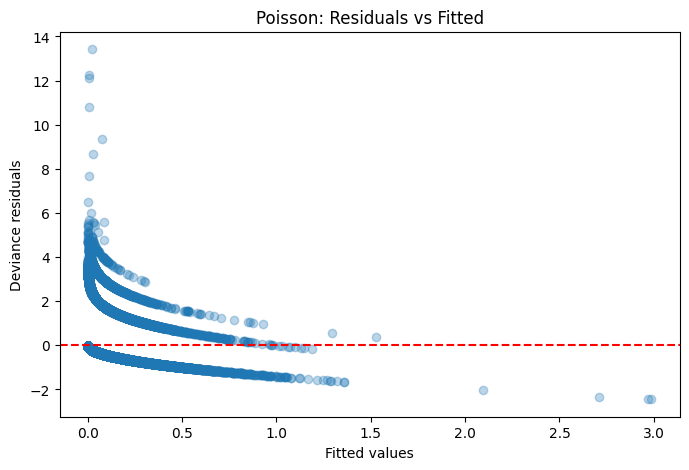

,0
count,542410.000000
mean,-0.175123
std,0.531324
min,-2.444435
25%,-0.379527
50%,-0.282744
75%,-0.159350
max,13.419816


In [25]:
fitted = fitted_models["formula_selected"].fittedvalues
resid_dev = fitted_models["formula_selected"].resid_deviance
resid_pearson = fitted_models["formula_selected"].resid_pearson

plt.figure(figsize=(8, 5))
plt.scatter(fitted, resid_dev, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Deviance residuals")
plt.title("Poisson: Residuals vs Fitted")
plt.show()
resid_dev.describe()

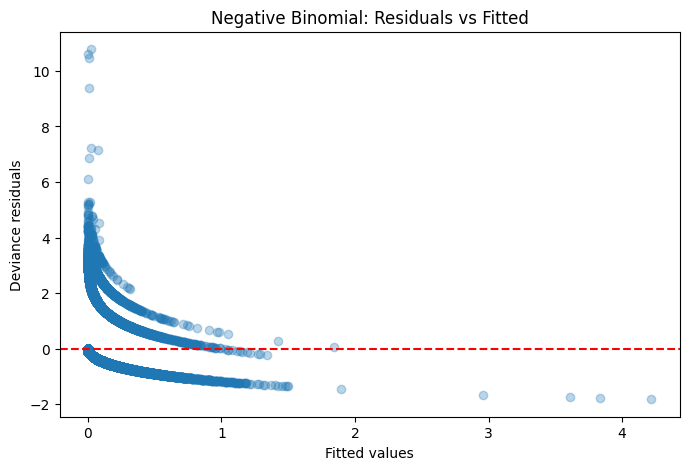

,0
count,542410.000000
mean,-0.181878
std,0.488488
min,-1.817979
25%,-0.374108
50%,-0.281042
75%,-0.159669
max,10.781322


In [26]:
fitted = fitted_modelsNB["formula_selected"].fittedvalues
resid_dev = fitted_modelsNB["formula_selected"].resid_deviance
resid_pearson = fitted_modelsNB["formula_selected"].resid_pearson

plt.figure(figsize=(8, 5))
plt.scatter(fitted, resid_dev, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Deviance residuals")
plt.title("Negative Binomial: Residuals vs Fitted")
plt.show()
resid_dev.describe()

**Takeaway:**

The residual plot of Poisson shows some **large deviance residuals**. Negative binomial improves  the fit somewhat, but some large deviance residuals are still visible. From the quantile summary, values up to the third quartile are still relatively small, so the large deviance residuals in the plots are **likely driven by outliers** in the data.

Next, we test whether the Negative Binomial model significantly improves the fit relative to the Poisson model.

### LR test

In [27]:
import scipy.stats as stats

pois = fitted_models["formula_selected"]
nb = fitted_modelsNB["formula_selected"]

lr_stat = 2 * (nb.llf - pois.llf)

# Common quick approximation:
p_value_chi2 = stats.chi2.sf(lr_stat, df=1)

print("LR statistic:", round(lr_stat, 4))
print("Chi-square p-value:", round(p_value_chi2,4))


LR statistic: 675.8982
Chi-square p-value: 0.0


Based on the likelihood ratio test, Negative Binomial is indeed a better fit.

## 2.4 Highlight on findings

### Regression result highlights (Negative Binomial)

First a regression summary is shown, and then is followed by a sorted table of coefficients.

In [28]:
fitted_modelsNB["formula_selected"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542365
Model Family:        NegativeBinomial   Df Model:                           44
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1224e+05
Date:                Mon, 08 Jun 2026   Deviance:                   1.4737e+05
Time:                        16:44:21   Pearson chi2:                 1.26e+06
No. Iterations:                    10   Pseudo R-squ. (CS):            0.01719
Covariance Type:            nonrobust                                         
=========================================================================================================================
                                                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
Intercept                                                -3.9056      0.132    -29.582      0.000      -4.164      -3.647
C(VehPower)[T.5]                                          0.1716      0.021      8.145      0.000       0.130       0.213
C(VehPower)[T.6]                                          0.2193      0.021     10.435      0.000       0.178       0.261
C(VehPower)[T.7]                                          0.1375      0.021      6.663      0.000       0.097       0.178
C(VehPower)[T.8]                                         -0.0884      0.031     -2.847      0.004      -0.149      -0.028
C(VehPower)[T.9]                                          0.2890      0.032      8.945      0.000       0.226       0.352
C(VehPower)[T.10]                                         0.2946      0.032      9.196      0.000       0.232       0.357
C(VehPower)[T.11]                                         0.1790      0.042      4.276      0.000       0.097       0.261
C(VehPower)[T.12]                                         0.0745      0.063      1.192      0.233      -0.048       0.197
C(VehPower)[T.13]                                         0.0313      0.097      0.322      0.748      -0.159       0.222
C(VehPower)[T.14]                                         0.1070      0.112      0.960      0.337      -0.112       0.326
C(VehPower)[T.15]                                        -0.1129      0.108     -1.047      0.295      -0.324       0.099
C(VehBrand_binned)[T.Others]                             -1.4321      0.039    -36.725      0.000      -1.509      -1.356
C(VehGas)[T.Regular]                                      0.0738      0.013      5.559      0.000       0.048       0.100
C(Region)[T.R21]                                          0.1493      0.096      1.560      0.119      -0.038       0.337
C(Region)[T.R22]                                          0.1268      0.059      2.134      0.033       0.010       0.243
C(Region)[T.R23]                                          0.0123      0.070      0.176      0.860      -0.124       0.149
C(Region)[T.R24]                                          0.1225      0.028      4.352      0.000       0.067       0.178
C(Region)[T.R25]                                          0.0566      0.052      1.078      0.281      -0.046       0.159
C(Region)[T.R26]                                          0.0964      0.056      1.726      0.084      -0.013       0.206
C(Region)[T.R31]                                         -0.0446      0.040     -1.106      0.269      -0.124       0.034
C(Region)[T.R41]                                         -0.2194      0.053     -4.178      0.000      -0.322      -0.116
C(Region)[T.R42]                 

In [29]:
effects_acend={
    "coefficient":fitted_modelsNB["formula_selected"].params,
    "pvalue": round(fitted_modelsNB["formula_selected"].pvalues, 4)
}
effects_acend=pd.DataFrame(effects_acend)
print("==============Sorted coefficient value==============")
effects_acend.sort_values("coefficient")

==============Sorted coefficient value==============


,coefficient,pvalue
Intercept,-3.905573,0.0000
np.log1p(VehAge),-2.446149,0.0000
C(VehBrand_binned)[T.Others],-1.432101,0.0000
I(np.log1p(VehAge) ** 2):C(VehBrand_binned)[T.Others],-0.813379,0.0000
C(Region)[T.R83],-0.239231,0.0053
C(Region)[T.R41],-0.219353,0.0000
C(VehPower)[T.15],-0.112915,0.2952
C(VehPower)[T.8],-0.088395,0.0044
C(Region)[T.R72],-0.076620,0.0506
C(Region)[T.R43],-0.068185,0.6724


### Findings on coefficients

`VehPower` generally has a **positive coefficient**, meaning that higher vehicle power is associated with a higher claim frequency than the base case, VehPower = 4. For the **highest-power vehicles**, the additional **effect appears insignificant**, so it may be reasonable to bin those categories.

`Log(VehAge)` has the largest negative effect on claim while `Log(VehAge)^2` is positive. This suggests that as a vehicle gets older, risk first decreases and then increases.



### For the further investigated

The positive coefficient of `BonusMalus` agrees with our [quantile mean plot](#scrollTo=HbJnb9EGqVeF&line=1&uniqifier=1).

Interaction term between `log(VehAge)` and `log(VehAge)^2` with `VehBrand_binned` are both significant. The magnitude of the coefficients makes the **opposite effect of `VehAge` on brand B12 against other brands**, i.e. overall B12 has decreasing linear and increasing quadratic effect on VehAge while brand others has the exact opposite.

`VehGas` and `Density` also agree with the [quantile mean plot by `VehGas`](#scrollTo=pgiRMb8MABBL).

# 3. Validation: Predictive performance on test data

We now compare three models on test data: Poisson, Negative Binomial, and Negative Binomial with Lasso regularization.

## 3.1 Lasso on Negative Binomial

We use a more general formula for the Lasso model, including `Area`, even though it was previously considered redundant.

In [30]:
formula_lasso=('ClaimNb ~ C(VehPower) + DrivAge + C(VehBrand_binned) + BonusMalus + C(VehGas)'
          '+ np.log(Density) + C(Region) + C(Area)'
          '+ I(DrivAge**2) + I(BonusMalus**2) + I(np.log(Density)**2)'
          '+ np.log1p(VehAge) + I(np.log1p(VehAge)**2) + np.log1p(VehAge):C(VehBrand_binned) + I(np.log1p(VehAge)**2):C(VehBrand_binned)'
)

penaltyAlpha_lasso=0.001778 # hard-coded from the result of a separate cross validation

y_lasso, X_lasso = patsy.dmatrices(formula_lasso, data=df_train, return_type="dataframe")

model_lasso=sm.GLM(y_lasso, X_lasso, family=sm.families.NegativeBinomial(), offset=offset)

result_lasso = model_lasso.fit_regularized(
    alpha=penaltyAlpha_lasso,
    L1_wt=1.0,
    maxiter=100,
    cnvrg_tol=1e-5,
    zero_tol=1e-6,
    refit=True
)
display(result_lasso.summary())



/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1464: UserWarning: Elastic net fitting did not converge
  warnings.warn("Elastic net fitting did not converge")


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542401
Model Family:        NegativeBinomial   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                   elastic_net   Log-Likelihood:            -1.1351e+05
Date:                Mon, 08 Jun 2026   Deviance:                   1.4992e+05
Time:                        16:51:25   Pearson chi2:                 1.29e+06
No. Iterations:                   100   Pseudo R-squ. (CS):            0.01256
Covariance Type:            nonrobust                                         
=========================================================================================================================
                                                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
Intercept                                                -3.8415      0.116    -33.041      0.000      -4.069      -3.614
C(VehPower)[T.5]                                               0          0        nan        nan           0           0
C(VehPower)[T.6]                                               0          0        nan        nan           0           0
C(VehPower)[T.7]                                               0          0        nan        nan           0           0
C(VehPower)[T.8]                                               0          0        nan        nan           0           0
C(VehPower)[T.9]                                               0          0        nan        nan           0           0
C(VehPower)[T.10]                                              0          0        nan        nan           0           0
C(VehPower)[T.11]                                              0          0        nan        nan           0           0
C(VehPower)[T.12]                                              0          0        nan        nan           0           0
C(VehPower)[T.13]                                              0          0        nan        nan           0           0
C(VehPower)[T.14]                                              0          0        nan        nan           0           0
C(VehPower)[T.15]                                              0          0        nan        nan           0           0
C(VehBrand_binned)[T.Others]                             -0.2647      0.019    -14.197      0.000      -0.301      -0.228
C(VehGas)[T.Regular]                                           0          0        nan        nan           0           0
C(Region)[T.R21]                                               0          0        nan        nan           0           0
C(Region)[T.R22]                                               0          0        nan        nan           0           0
C(Region)[T.R23]                                               0          0        nan        nan           0           0
C(Region)[T.R24]                                               0          0        nan        nan           0           0
C(Region)[T.R25]                                               0          0        nan        nan           0           0
C(Region)[T.R26]                                               0          0        nan        nan           0           0
C(Region)[T.R31]                                               0          0        nan        nan           0           0
C(Region)[T.R41]                                               0          0        nan        nan           0           0
C(Region)[T.R42]                 

In [31]:
effects_acend={
    "coefficient_NBlasso":result_lasso.params,
}
effects_acend=pd.DataFrame(effects_acend)
effects_acend.index = X_lasso.columns
effects_acend=effects_acend[effects_acend["coefficient_NBlasso"]!=0]
effects_acend["coefficient_NB"]=fitted_modelsNB["formula_selected"].params[effects_acend.index]
print("==============Sorted coefficient values comparison==============")
effects_acend.sort_values("coefficient_NBlasso")

==============Sorted coefficient values comparison==============


,coefficient_NBlasso,coefficient_NB
Intercept,-3.841540,-3.905573
np.log1p(VehAge),-0.715062,-2.446149
C(VehBrand_binned)[T.Others],-0.264737,-1.432101
I(DrivAge ** 2),-0.000181,-0.000209
I(BonusMalus ** 2),-0.000041,-0.000045
I(np.log(Density) ** 2),0.002774,-0.003568
DrivAge,0.025682,0.028870
BonusMalus,0.029994,0.030804
I(np.log1p(VehAge) ** 2):C(VehBrand_binned)[T.Others],0.143342,-0.813379


**Finding**:

The **signs of the variables selected** by the Lasso version of the Negative Binomial generally agree with those in the original Negative Binomial. Only the two squared terms (`Density` and the `VehAge` interaction term) have different signs. This is likely because their linear counterparts were dropped, causing the squared terms to absorb their effects.

## 3.2 Out-of-sample Validation

Now we have our 3 models (Poisson, Negative Binomial, and Negative Binomial(lasso)), we are going to test their performance aginst test data.

### Prediction on test data

In [32]:
df_test["VehBrand_binned"] = np.where(
    df_test["VehBrand"] == "B12", "B12", "Others"
)

offset_test = np.log(df_test["Exposure"])
formula = formulas["formula_selected"]

y_test, X_test = patsy.dmatrices(formula, data=df_test, return_type="dataframe")
y_test = np.asarray(y_test).ravel()

res_pois = fitted_models["formula_selected"]
res_nb   = fitted_modelsNB["formula_selected"]

mu_pois = res_pois.predict(X_test, offset=offset_test)
mu_nb   = res_nb.predict(X_test, offset=offset_test)

y_test_lasso, X_test_lasso = patsy.dmatrices(formula_lasso, data=df_test, return_type="dataframe")
y_test_lasso = np.asarray(y_test_lasso).ravel()

mu_lasso = result_lasso.predict(X_test_lasso, offset=offset_test)

### Log score

In [33]:

from scipy.stats import poisson, nbinom

# Poisson log score
prob_pois = poisson.pmf(y_test.astype(int), mu_pois)
prob_pois = np.clip(prob_pois, 1e-15, None)
test_logscore_pois = -np.mean(np.log(prob_pois))

# NB log score
nb_dispersion_alpha = 1.0   # replace if you used another fixed NB family alpha
size = 1 / nb_dispersion_alpha

p_nb = size / (size + mu_nb)
prob_nb = nbinom.pmf(y_test.astype(int), size, p_nb)
prob_nb = np.clip(prob_nb, 1e-15, None)
test_logscore_nb = -np.mean(np.log(prob_nb))

# NB-lasso log score
p_lasso = size / (size + mu_lasso)
prob_lasso = nbinom.pmf(y_test_lasso.astype(int), size, p_lasso)
prob_lasso = np.clip(prob_lasso, 1e-15, None)
test_logscore_lasso = -np.mean(np.log(prob_lasso))

print("NB test mean log score:", test_logscore_nb)
print("Poisson test mean log score:", test_logscore_pois)
print("NB-lasso test mean log score:", test_logscore_lasso)

NB test mean log score: 0.20855746985842255
Poisson test mean log score: 0.2089845348952773
NB-lasso test mean log score: 0.21053160993447728


Log scores show Negative Binomial has the best predictive performance.

### Decile plots

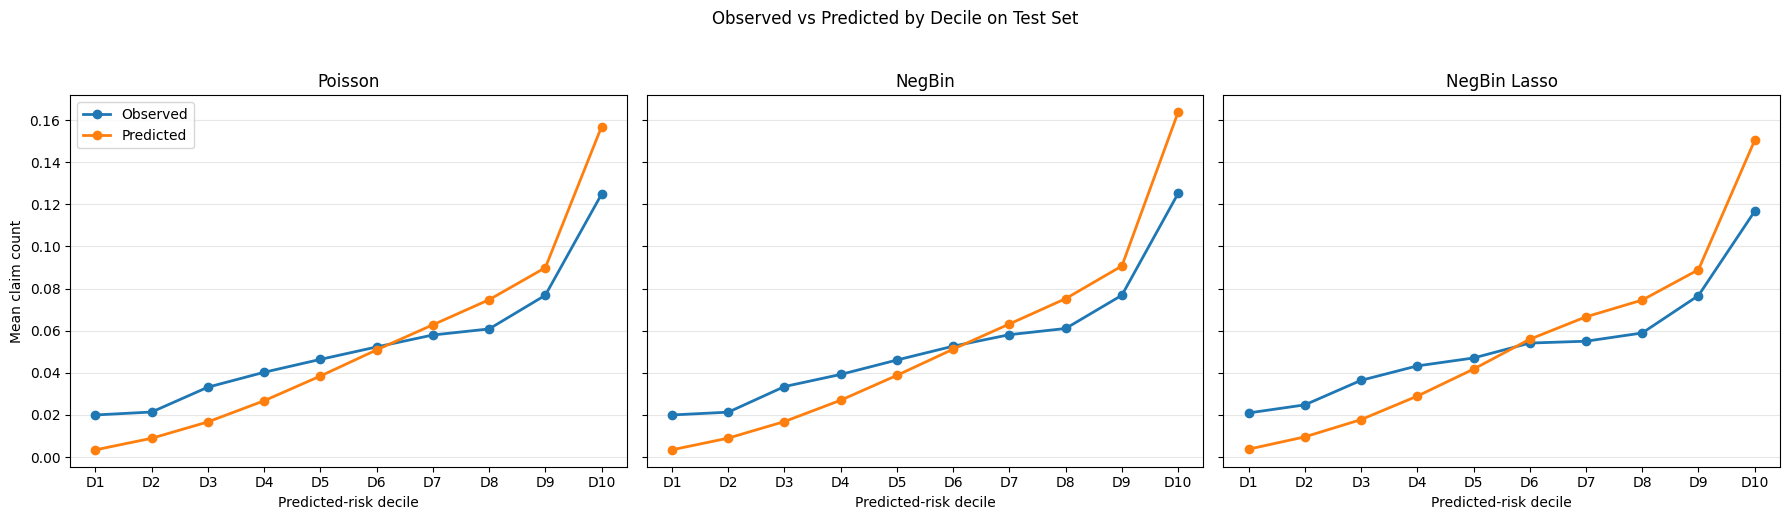

In [34]:


def make_decile_summary(y_true, y_pred, n_bins=10):
    df_plot = pd.DataFrame({
        "observed": np.asarray(y_true).ravel(),
        "predicted": np.asarray(y_pred).ravel()
    }).copy()

    # decile 1 = lowest predicted, decile 10 = highest predicted
    df_plot["decile"] = pd.qcut(
        df_plot["predicted"],
        q=n_bins,
        labels=[f"D{i}" for i in range(1, n_bins + 1)],
        duplicates="drop"
    )

    decile_summary = (
        df_plot.groupby("decile", observed=False)
        .agg(
            observed_mean=("observed", "mean"),
            predicted_mean=("predicted", "mean"),
            n=("observed", "size")
        )
        .reset_index()
    )

    return decile_summary

# build summaries
dec_pois = make_decile_summary(y_test, mu_pois, n_bins=10)
dec_nb = make_decile_summary(y_test, mu_nb, n_bins=10)
dec_lasso = make_decile_summary(y_test_lasso, mu_lasso, n_bins=10)

# plot side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

plot_list = [
    ("Poisson", dec_pois, axes[0]),
    ("NegBin", dec_nb, axes[1]),
    ("NegBin Lasso", dec_lasso, axes[2]),
]

for title, dec_df, ax in plot_list:
    x = np.arange(len(dec_df))

    ax.plot(x, dec_df["observed_mean"], marker="o", linewidth=2, label="Observed")
    ax.plot(x, dec_df["predicted_mean"], marker="o", linewidth=2, label="Predicted")

    ax.set_xticks(x)
    ax.set_xticklabels(dec_df["decile"], rotation=0)
    ax.set_xlabel("Predicted-risk decile")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Mean claim count")
axes[0].legend()

fig.suptitle("Observed vs Predicted by Decile on Test Set", y=1.03)
plt.tight_layout()
plt.show()

# print("Poisson")
# print(dec_pois)

# print("\nNegBin")
# print(dec_nb)

# print("\nNegBin Lasso")
# print(dec_lasso)

**Takeaway:**

The decile plots show a consistent **underprediction before D6** and **overprediction after D6** across all three models. This may be the result of excess zeros and outliers in the data.

Next we take a closer look of predictive performance for `VehBrand_binned`.

### Decile plots by VehBrand_binned

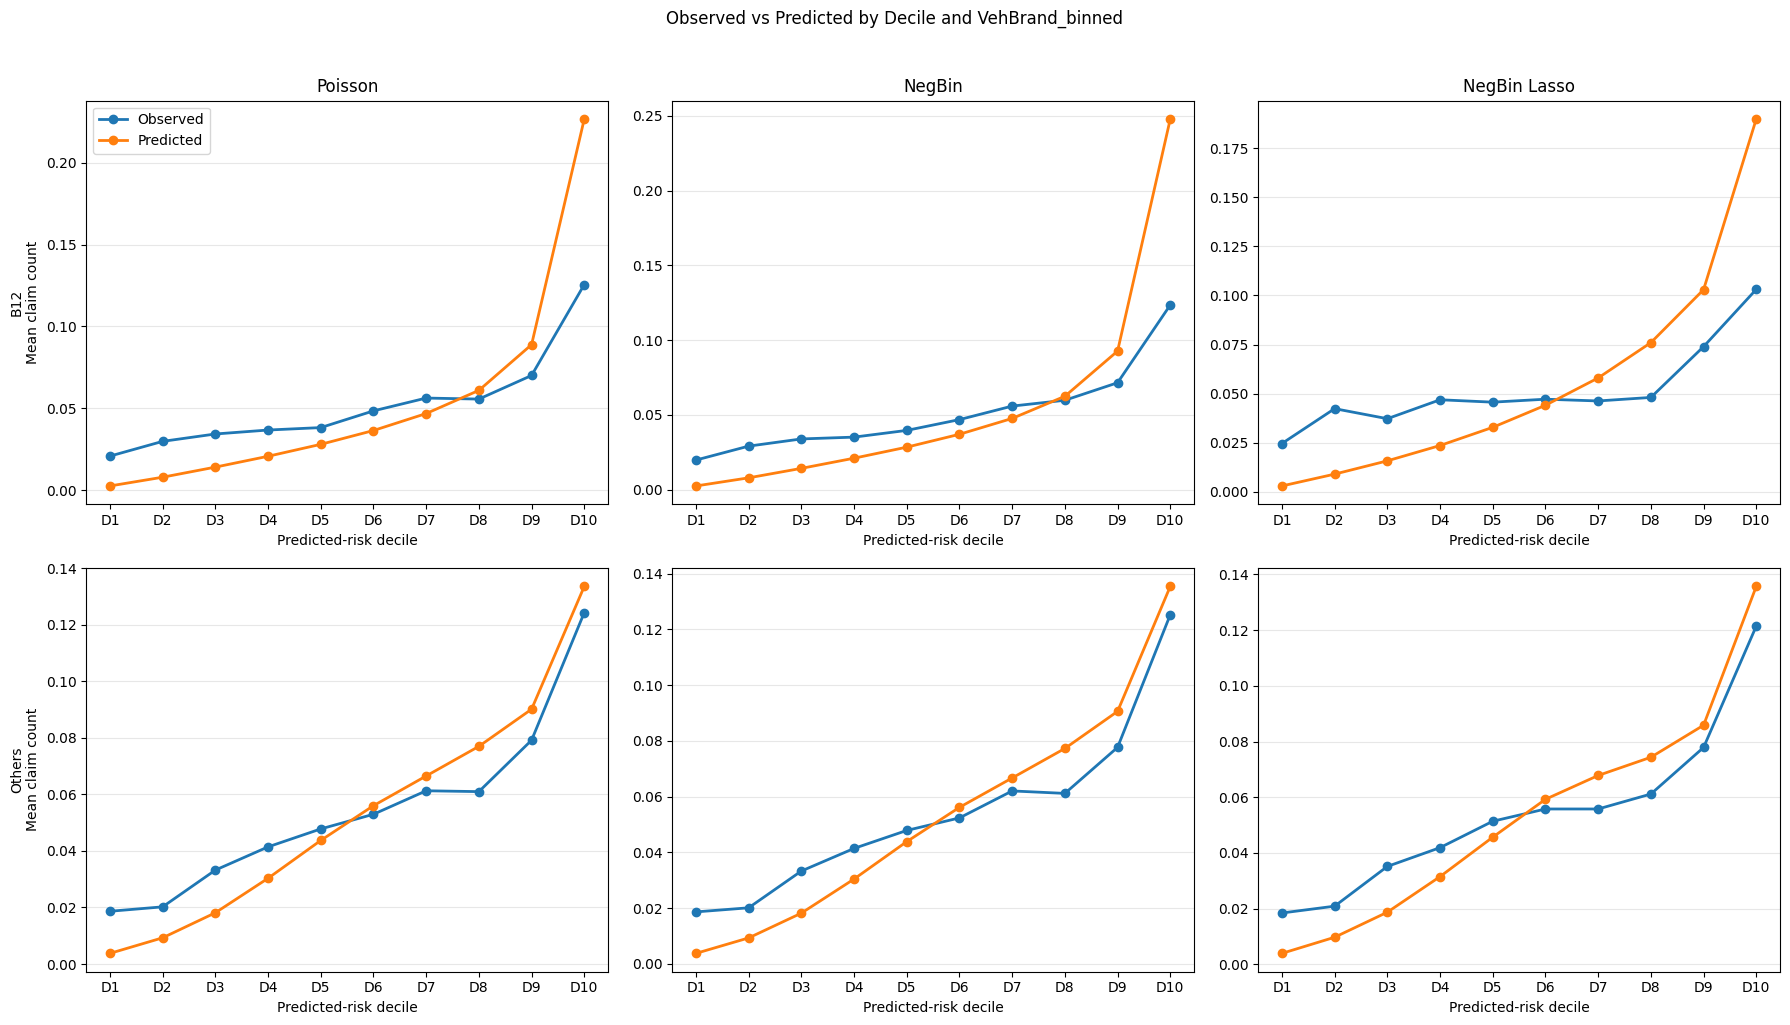

In [35]:

def make_decile_summary_by_group(y_true, y_pred, group, n_bins=10):
    df_plot = pd.DataFrame({
        "observed": np.asarray(y_true).ravel(),
        "predicted": np.asarray(y_pred).ravel(),
        "group": np.asarray(group)
    }).copy()

    out = []

    for g, dfg in df_plot.groupby("group"):
        dfg = dfg.copy()

        # create deciles within each group
        dfg["decile"] = pd.qcut(
            dfg["predicted"],
            q=n_bins,
            labels=[f"D{i}" for i in range(1, n_bins + 1)],
            duplicates="drop"
        )

        dec = (
            dfg.groupby("decile", observed=False)
            .agg(
                observed_mean=("observed", "mean"),
                predicted_mean=("predicted", "mean"),
                n=("observed", "size")
            )
            .reset_index()
        )

        dec["group"] = g
        out.append(dec)

    return pd.concat(out, ignore_index=True)

# summaries by VehBrand_binned
dec_pois_brand = make_decile_summary_by_group(
    y_true=y_test,
    y_pred=mu_pois,
    group=df_test["VehBrand_binned"],
    n_bins=10
)

dec_nb_brand = make_decile_summary_by_group(
    y_true=y_test,
    y_pred=mu_nb,
    group=df_test["VehBrand_binned"],
    n_bins=10
)

dec_lasso_brand = make_decile_summary_by_group(
    y_true=y_test_lasso,
    y_pred=mu_lasso,
    group=df_test["VehBrand_binned"],
    n_bins=10
)

# plot: rows = brand group, cols = model
brand_levels = sorted(df_test["VehBrand_binned"].dropna().unique())
fig, axes = plt.subplots(len(brand_levels), 3, figsize=(18, 5 * len(brand_levels)), sharey=False)

# handle case of only one row
if len(brand_levels) == 1:
    axes = np.array([axes])

plot_tables = {
    "Poisson": dec_pois_brand,
    "NegBin": dec_nb_brand,
    "NegBin Lasso": dec_lasso_brand
}

for i, brand in enumerate(brand_levels):
    for j, (model_name, dec_df) in enumerate(plot_tables.items()):
        ax = axes[i, j]
        d = dec_df[dec_df["group"] == brand].copy()

        x = np.arange(len(d))

        ax.plot(x, d["observed_mean"], marker="o", linewidth=2, label="Observed")
        ax.plot(x, d["predicted_mean"], marker="o", linewidth=2, label="Predicted")

        ax.set_xticks(x)
        ax.set_xticklabels(d["decile"], rotation=0)
        ax.set_xlabel("Predicted-risk decile")
        ax.grid(axis="y", alpha=0.3)

        if i == 0:
            ax.set_title(model_name)

        if j == 0:
            ax.set_ylabel(f"{brand}\nMean claim count")

        if i == 0 and j == 0:
            ax.legend()

fig.suptitle("Observed vs Predicted by Decile and VehBrand_binned", y=1.02)
plt.tight_layout()
plt.show()


# print("Poisson brand")
# print(dec_pois_brand)

# print("\nNegBin brand")
# print(dec_nb_brand)

# print("\nNegBin Lasso brand")
# print(dec_lasso_brand)

**Takeaway**:

The decile plots by `VehBrand_binned` show that **B12 performs poorly at the higher deciles** across all three models, and it appears to be an important contributor of the weak performance at high-risk cases. This suggests that some modifications to the modeling approach for B12 may be needed.

# 4. Monte Carlo simulation

As noted earlier, `VehBrand` = B12 and `BonusMalus` were identified as important risk factors in the fitted frequency model. A natural business question is therefore: what is the distribution of aggregate claim counts for policyholders driving B12 cars with `BonusMalus` > 100?

## 4.1 Re-fitting full data
The selected Negative Binomial model is refitted on the **full dataset** so that the simulation uses all available observations.

In [36]:
offset_full=np.log(df["Exposure"])
df["VehBrand_binned"] = np.where(
    df["VehBrand"] == "B12", "B12", "Others"
)
y, X = patsy.dmatrices(formula, data=df, return_type="dataframe")
modelNB_full = sm.GLM(y, X, family=sm.families.NegativeBinomial(), offset=offset_full)
res_full = modelNB_full.fit()
res_full.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   677968
Model Family:        NegativeBinomial   Df Model:                           44
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4051e+05
Date:                Mon, 08 Jun 2026   Deviance:                   1.8454e+05
Time:                        16:52:12   Pearson chi2:                 1.58e+06
No. Iterations:                     9   Pseudo R-squ. (CS):            0.01685
Covariance Type:            nonrobust                                         
=========================================================================================================================
                                                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
Intercept                                                -3.9091      0.119    -32.904      0.000      -4.142      -3.676
C(VehPower)[T.5]                                          0.1932      0.019     10.256      0.000       0.156       0.230
C(VehPower)[T.6]                                          0.2297      0.019     12.205      0.000       0.193       0.267
C(VehPower)[T.7]                                          0.1433      0.019      7.742      0.000       0.107       0.180
C(VehPower)[T.8]                                         -0.0810      0.028     -2.907      0.004      -0.136      -0.026
C(VehPower)[T.9]                                          0.3169      0.029     11.031      0.000       0.261       0.373
C(VehPower)[T.10]                                         0.2870      0.029      9.970      0.000       0.231       0.343
C(VehPower)[T.11]                                         0.1845      0.038      4.912      0.000       0.111       0.258
C(VehPower)[T.12]                                         0.0542      0.056      0.960      0.337      -0.056       0.165
C(VehPower)[T.13]                                         0.0742      0.085      0.875      0.382      -0.092       0.240
C(VehPower)[T.14]                                         0.1931      0.096      2.009      0.045       0.005       0.381
C(VehPower)[T.15]                                        -0.0547      0.094     -0.585      0.559      -0.238       0.129
C(VehBrand_binned)[T.Others]                             -1.4081      0.035    -40.388      0.000      -1.476      -1.340
C(VehGas)[T.Regular]                                      0.0752      0.012      6.339      0.000       0.052       0.098
C(Region)[T.R21]                                          0.1742      0.084      2.063      0.039       0.009       0.340
C(Region)[T.R22]                                          0.1156      0.054      2.153      0.031       0.010       0.221
C(Region)[T.R23]                                         -0.0079      0.062     -0.126      0.900      -0.130       0.115
C(Region)[T.R24]                                          0.1093      0.025      4.349      0.000       0.060       0.159
C(Region)[T.R25]                                          0.0613      0.047      1.317      0.188      -0.030       0.152
C(Region)[T.R26]                                          0.0437      0.051      0.860      0.390      -0.056       0.143
C(Region)[T.R31]                                         -0.0705      0.036     -1.951      0.051      -0.141       0.000
C(Region)[T.R41]                                         -0.2153      0.047     -4.609      0.000      -0.307      -0.124
C(Region)[T.R42]                 

## 4.2 Simulation on the subgroup

In [37]:
df_sim = df[(df["VehBrand_binned"] == "B12") & (df["BonusMalus"] > 100)]

# Build X_sim using the design_info from training X matrix
X_sim = patsy.build_design_matrices([X.design_info], data=df_sim, return_type="dataframe")[0]

# fitted NB mean
mu_sim = res_full.predict(X_sim, offset=np.log(df_sim["Exposure"]))

# convert mean/alpha to numpy Negative Binomial parameters
r = 1 # as dispersion parameter in NB is set to 1
p = r / (r + mu_sim.to_numpy())

n_sim = 100000
sim_counts_nb = np.random.negative_binomial(
    n=r,
    p=np.tile(p, (n_sim, 1))
)
sim_total_nb = sim_counts_nb.sum(axis=1)

pd.Series(sim_total_nb).describe(percentiles=[0.05, 0.3, 0.5, 0.8, 0.95])

,0
count,100000.000000
mean,287.237770
std,20.359264
min,206.000000
5%,254.000000
30%,276.000000
50%,287.000000
80%,304.000000
95%,321.000000
max,382.000000


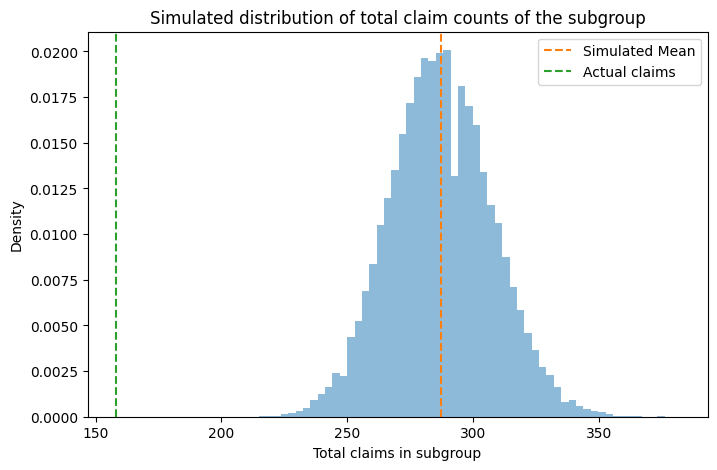

In [38]:
claim_actual= df_sim['ClaimNb'].sum()

plt.figure(figsize=(8,5))
plt.hist(sim_total_nb, bins=60, alpha=0.5, density=True)
plt.axvline(sim_total_nb.mean(), color="C1", linestyle="--", label="Simulated Mean")
plt.axvline(claim_actual, color="C2", linestyle="--", label="Actual claims")
plt.xlabel("Total claims in subgroup")
plt.ylabel("Density")
plt.title("Simulated distribution of total claim counts of the subgroup")
plt.legend()
plt.show()

**Takeaway:**

For each policyholder in the subgroup, claim count is simulated from the fitted Negative Binomial distribution and summed across policies to obtain the simulated distribution of aggregate subgroup claim counts.

We can see that the **observed subgroup total lies far from the simulated distribution**. This suggests that the fitted Negative Binomial model does not capture this subgroup particularly well, which is consistent with the earlier results: the earlier diagnostics about remaining overdispersion in the model; and validation on higher-risk groups tend to be overpredicted.


# Final thoughts

Model fit and predictive performance could potentially be improved by using more advanced models, such as zero-inflated models.

Outliers are also a concern, as seen in the residual plots, and their effects likely carry over into prediction. Some domain knowledge could be used to guide data transformations, such as capping certain variables.

There are also additional opportunities for feature engineering, as this project did not explore `Region` in depth or investigate more complex higher-dimensional relationships among predictors.